# Pertemuan 12 — Asosiasi Data & Rekomendasi

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [1]:
# Install library mlxtend (diperlukan untuk Apriori)
!pip install mlxtend -q

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


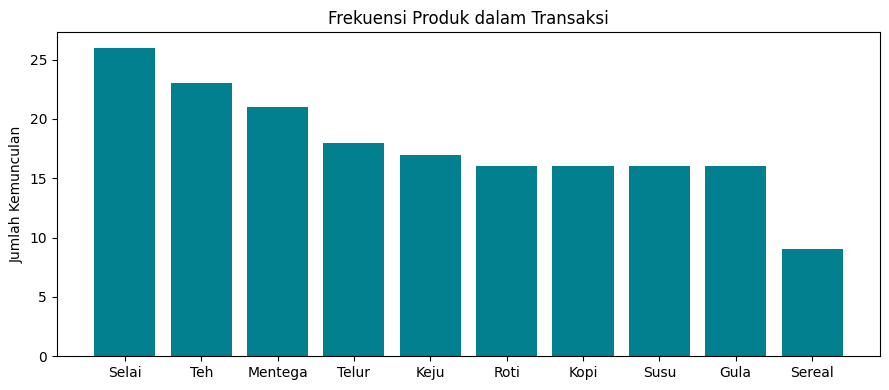

In [2]:
# Langkah 1: Generate & Eksplorasi Dataset Transaksi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

# Frekuensi tiap produk
from collections import Counter
freq_produk = Counter([item for t in transaksi for item in t])
freq_df = pd.DataFrame(freq_produk.items(), columns=['Produk','Frekuensi']).sort_values('Frekuensi', ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(freq_df['Produk'], freq_df['Frekuensi'], color='#028090')
plt.title('Frekuensi Produk dalam Transaksi')
plt.ylabel('Jumlah Kemunculan')
plt.tight_layout()
plt.show()

In [3]:
# Langkah 2: One-Hot Encoding Transaksi
from mlxtend.preprocessing import TransactionEncoder

te     = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df     = pd.DataFrame(te_ary, columns=te.columns_)

print('Shape one-hot encoding:', df.shape)
print(df.head())

Shape one-hot encoding: (50, 10)
    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


In [4]:
# Langkah 3: Cari Frequent Itemset dengan Apriori
from mlxtend.frequent_patterns import apriori

# Coba beberapa nilai min_support
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support=0.1
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)

print('\nTop 10 Frequent Itemset:')
print(freq_items.head(10).to_string(index=False))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

Top 10 Frequent Itemset:
 support     itemsets
    0.52      (Selai)
    0.46        (Teh)
    0.42    (Mentega)
    0.36      (Telur)
    0.34       (Keju)
    0.32       (Gula)
    0.32       (Kopi)
    0.32       (Roti)
    0.32       (Susu)
    0.24 (Teh, Selai)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Langkah 4: Bentuk & Saring Aturan Asosiasi
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print('Jumlah aturan ditemukan:', len(rules))
print('\nTop 10 Aturan Asosiasi (berdasarkan Lift):')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

Jumlah aturan ditemukan: 16

Top 10 Aturan Asosiasi (berdasarkan Lift):
     antecedents consequents  support  confidence     lift
     (Teh, Keju)     (Telur)     0.12    0.857143 2.380952
(Mentega, Selai)      (Kopi)     0.10    0.625000 1.953125
    (Gula, Roti)     (Selai)     0.10    1.000000 1.923077
        (Sereal)   (Mentega)     0.14    0.777778 1.851852
    (Teh, Telur)      (Keju)     0.12    0.600000 1.764706
   (Kopi, Selai)   (Mentega)     0.10    0.714286 1.700680
   (Keju, Telur)       (Teh)     0.12    0.750000 1.630435
   (Gula, Selai)      (Roti)     0.10    0.500000 1.562500
 (Kopi, Mentega)     (Selai)     0.10    0.714286 1.373626
          (Roti)     (Selai)     0.22    0.687500 1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretasi Aturan Asosiasi

**Aturan dengan Lift tertinggi** adalah yang paling menarik secara bisnis. Lift > 1 berarti kedua produk lebih sering dibeli bersamaan dibanding jika dibeli secara acak.

Aturan **Roti → Selai** muncul dengan confidence dan lift tinggi — ini memang sesuai dengan pola yang kita suntikkan ke dataset. Secara bisnis, ini bisa dijadikan dasar untuk strategi bundling produk atau penempatan rak di toko yang saling berdekatan.


In [6]:
# Langkah 5: Rekomender Sederhana dengan Content-Based Filtering
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk'  : produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur      = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx  = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Katalog produk:')
print(katalog.to_string(index=False))
print()
for p in ['Roti', 'Susu', 'Kopi']:
    print(f'Mirip dengan {p}:', rekomendasi_serupa(p))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Katalog produk:
 produk kategori
   Roti   Bakery
  Selai   Bakery
   Susu    Dairy
 Sereal   Bakery
  Telur    Dairy
   Keju    Dairy
   Kopi  Minuman
   Gula    Bumbu
    Teh  Minuman
Mentega    Dairy

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu: ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi: ['Teh', 'Roti', 'Selai']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# Langkah 6: Bandingkan Kedua Pendekatan
produk_target = 'Roti'

# Rekomendasi dari Association Rules
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head().to_string(index=False))

print()
print('Rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
consequents     lift
    (Selai) 1.923077
    (Selai) 1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Perbandingan Association Rules vs Content-Based Filtering

**Association Rules** merekomendasikan produk berdasarkan pola pembelian nyata dari transaksi — hasilnya lebih mencerminkan perilaku pelanggan aktual. Kelemahannya butuh data transaksi yang cukup banyak agar aturan yang terbentuk bermakna.

**Content-Based Filtering** merekomendasikan berdasarkan kemiripan atribut produk (kategori). Keunggulannya tidak butuh data transaksi sama sekali, sehingga bisa langsung berjalan bahkan untuk produk baru yang belum pernah terjual.

Untuk kasus toko nyata, pendekatan **hybrid** (menggabungkan keduanya) biasanya memberikan hasil terbaik — gunakan content-based untuk produk baru, dan association rules untuk produk yang sudah punya riwayat transaksi cukup.


## Kesimpulan — Pertemuan 12: Asosiasi Data & Rekomendasi

Pertemuan ini memperkenalkan dua pendekatan yang cukup berbeda dari ML sebelumnya. Apriori bekerja dengan mencari pola co-occurrence di data transaksi — bukan memprediksi label, tapi menemukan "kebiasaan" pembelian yang tersembunyi.

Yang menarik adalah bagaimana tiga metrik (support, confidence, lift) harus dibaca bersamaan. Confidence tinggi saja tidak cukup — lift yang tinggi yang benar-benar menunjukkan bahwa hubungan antar produk bukan sekadar kebetulan karena salah satunya memang populer.

Content-Based Filtering terasa lebih simpel secara konsep, tapi punya keterbatasan karena hanya mengandalkan atribut yang kita definisikan sendiri. Kombinasi keduanya sepertinya lebih masuk akal untuk diterapkan di kasus nyata.
